In [ ]:
from google.colab import drive
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')

# --- SETTINGS ---
BASE_PATH = '/content/drive/MyDrive/nutrient-deficiency'
IMG_SIZE = 224
BATCH_SIZE = 32

crop_map = {'rice_deficiency': 0, 'maize_deficiency': 1, 'coffee_deficiency': 2}
label_map = {'Nitrogen(N)': 0, 'Phosphorus(P)': 1, 'Potassium(K)': 2, 'Healthy': 3}

Mounted at /content/drive


In [ ]:
# Create the Master List
data = []
for crop_folder, crop_id in crop_map.items():
    crop_path = os.path.join(BASE_PATH, crop_folder)
    for label_name, label_id in label_map.items():
        f_path = os.path.join(crop_path, label_name)
        if os.path.exists(f_path):
            for img in os.listdir(f_path):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    data.append([os.path.join(f_path, img), crop_id, label_id])

df = pd.DataFrame(data, columns=['filepath', 'crop_id', 'label_id'])
df.head()

,filepath,crop_id,label_id
0,/content/drive/MyDrive/nutrient-deficiency/ric...,0,0
1,/content/drive/MyDrive/nutrient-deficiency/ric...,0,0
2,/content/drive/MyDrive/nutrient-deficiency/ric...,0,0
3,/content/drive/MyDrive/nutrient-deficiency/ric...,0,0
4,/content/drive/MyDrive/nutrient-deficiency/ric...,0,0


In [ ]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label_id'], random_state=42)

In [ ]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img

In [ ]:
# Training Dataset Pipeline
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filepath'], train_df['crop_id'], train_df['label_id']))
train_ds = train_ds.map(lambda f, c, l: (
    (load_image(f), tf.one_hot(c, 3)),
    tf.one_hot(l, 4)
), num_parallel_calls=tf.data.AUTOTUNE).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Validation Dataset Pipeline
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filepath'], val_df['crop_id'], val_df['label_id']))
val_ds = val_ds.map(lambda f, c, l: (
    (load_image(f), tf.one_hot(c, 3)),
    tf.one_hot(l, 4)
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# --- BUILD MODEL ---
img_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
crop_in = layers.Input(shape=(3,), name="crop_input")

# Image Backbone
base = tf.keras.applications.EfficientNetV2S(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base.trainable = False

x = layers.GlobalAveragePooling2D()(base(img_in))
x = layers.Dropout(0.3)(x)

# Fusion
y = layers.Dense(16, activation='relu')(crop_in)
merged = layers.Concatenate()([x, y])
z = layers.Dense(256, activation='relu')(merged)
z = layers.Dropout(0.4)(z)
out = layers.Dense(4, activation='softmax')(z)

model = models.Model(inputs=[img_in, crop_in], outputs=out)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- 1. IMAGE INPUT BRANCH ---
img_input = layers.Input(shape=(224, 224, 3), name="image_input")

# Load EfficientNetV2-S without the top classification layers
base_model = tf.keras.applications.EfficientNetV2S(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Keep the pre-trained weights frozen for now

# Process image features
x = base_model(img_input)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

# --- 2. CROP ID INPUT BRANCH ---
# Input for Crop Type: Rice, Maize, Coffee (One-hot encoded, length 3)
crop_input = layers.Input(shape=(3,), name="crop_input")
y = layers.Dense(16, activation='relu')(crop_input)

# --- 3. THE FUSION ---
# Merging the visual features with the crop metadata
combined = layers.Concatenate()([x, y])

# Final Classification Head
z = layers.Dense(128, activation='relu')(combined)
z = layers.Dropout(0.3)(z)

# Output: 3 Classes (Stage 1, 2, or 3)
output = layers.Dense(3, activation='softmax', name="stage_output")(z)

# --- 4. ASSEMBLE & COMPILE ---
growth_model = models.Model(inputs=[img_input, crop_input], outputs=output)

growth_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print the architecture to verify the connections
growth_model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-s    │ (None, 7, 7,      │ 20,331,360 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_input          │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │         64 │ crop_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 272)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     34,944 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_output        │ (None, 3)         │        387 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,694,691 (78.94 MB)

 Trainable params: 363,331 (1.39 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [ ]:
import tensorflow as tf

# Path where your model is saved
model_path = '/content/drive/MyDrive/nutrient-deficiency/best_growth_fusion_model.keras'

# Load the model
growth_model = tf.keras.models.load_model(model_path)

# UNFREEZE: Allow the pre-trained layers to adjust to your specific data
growth_model.trainable = True

# Re-compile with a MUCH smaller learning rate (1e-5)
# Using a high rate like 1e-3 now would ruin the progress you've made
growth_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model loaded and unfrozen for fine-tuning.")

✅ Model loaded and unfrozen for fine-tuning.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# New save path for the improved version
refined_checkpoint = '/content/drive/MyDrive/nutrient-deficiency/best_growth_fusion_model_v2.keras'

callbacks = [
    ModelCheckpoint(refined_checkpoint, save_best_only=True, monitor='val_accuracy', mode='max'),
    # If val_loss doesn't improve for 2 epochs, drop the learning rate further
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7),
    # Stop if it starts overfitting (val_loss going up while train_loss goes down)
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
]

print("🚀 Continuing training to push past 82.64%...")
history = growth_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

🚀 Continuing training to push past 82.64%...
Epoch 1/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 3209s 14s/step - accuracy: 0.7709 - loss: 0.5424 - val_accuracy: 0.8252 - val_loss: 0.4202 - learning_rate: 1.0000e-05
Epoch 2/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 137s 611ms/step - accuracy: 0.7708 - loss: 0.5333 - val_accuracy: 0.8264 - val_loss: 0.4194 - learning_rate: 1.0000e-05
Epoch 3/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 136s 606ms/step - accuracy: 0.7687 - loss: 0.5353 - val_accuracy: 0.8264 - val_loss: 0.4200 - learning_rate: 1.0000e-05
Epoch 4/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 121s 514ms/step - accuracy: 0.7734 - loss: 0.5277 - val_accuracy: 0.8247 - val_loss: 0.4209 - learning_rate: 1.0000e-05
Epoch 5/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 141s 509ms/step - accuracy: 0.7720 - loss: 0.5320 - val_accuracy: 0.8252 - val_loss: 0.4211 - learning_rate: 2.0000e-06
Epoch 6/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 131s 587ms/step - accuracy: 0.7715 - loss: 0.5292 - val_accuracy: 0.8230 - val_loss: 0.4209 - learning_rate: 2.0000e

#run from here


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# --- CONFIGURATION ---

BASE_PATH = '/content/drive/MyDrive/nutrient-deficiency'
CROP_FOLDERS = {
    'rice_growth_stage': 0,
    'maize_growth_stage': 1,
    'coffee_growth_stage': 2
}
# We map your folder names (1, 2, 3) to 0-indexed labels (0, 1, 2)
STAGE_MAP = {'1': 0, '2': 1, '3': 2}

# --- DATA COLLECTION ---
all_data = []
for crop_name, crop_id in CROP_FOLDERS.items():
    crop_dir = os.path.join(BASE_PATH, crop_name)
    for stage_folder, stage_id in STAGE_MAP.items():
        folder_path = os.path.join(crop_dir, stage_folder)
        if os.path.exists(folder_path):
            images = [os.path.join(folder_path, f) for f in os.listdir(folder_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            for img_path in images:
                all_data.append({'filepath': img_path, 'crop_id': crop_id, 'stage_id': stage_id})

df = pd.DataFrame(all_data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df[['crop_id', 'stage_id']], random_state=42)

print(f"✅ Dataset Loaded: {len(df)} total images.")

✅ Dataset Loaded: 8954 total images.


In [ ]:
import tensorflow as tf

def load_and_preprocess(filepath, crop_id, stage_id):
    # 1. Load and process Image
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224]) / 255.0

    # 2. Convert IDs to One-Hot (3 classes each)
    crop_oh = tf.one_hot(crop_id, 3)
    stage_oh = tf.one_hot(stage_id, 3)

    # Return: ( [Image, CropID], StageID )
    return (img, crop_oh), stage_oh

# Create the Training Dataset
train_gen = tf.data.Dataset.from_tensor_slices((
    train_df['filepath'].values,
    train_df['crop_id'].values,
    train_df['stage_id'].values
))

train_gen = train_gen.shuffle(len(train_df)).map(load_and_preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

# Create the Validation Dataset
val_gen = tf.data.Dataset.from_tensor_slices((
    val_df['filepath'].values,
    val_df['crop_id'].values,
    val_df['stage_id'].values
))

val_gen = val_gen.map(load_and_preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

print("✅ Data pipeline is ready using tf.data!")

✅ Data pipeline is ready using tf.data!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd

IMG_SIZE = 300
BATCH_SIZE = 20 # Lowered batch size to 16 to avoid 'Out of Memory' at 300px

def load_and_preprocess_300(filepath, crop_id, stage_id, augment=True):
    # Image processing
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)

    img = img / 255.0

    # Dual inputs and labels
    crop_oh = tf.one_hot(crop_id, 3)
    stage_oh = tf.one_hot(stage_id, 3)

    return (img, crop_oh), stage_oh

# Create Datasets
train_gen = tf.data.Dataset.from_tensor_slices((
    train_df['filepath'].values, train_df['crop_id'].values, train_df['stage_id'].values
)).shuffle(len(train_df)).map(lambda f, c, s: load_and_preprocess_300(f, c, s, augment=True)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_gen = tf.data.Dataset.from_tensor_slices((
    val_df['filepath'].values, val_df['crop_id'].values, val_df['stage_id'].values
)).map(lambda f, c, s: load_and_preprocess_300(f, c, s, augment=False)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. LOAD YOUR EXISTING 82% MODEL
old_model_path = '/content/drive/MyDrive/nutrient-deficiency/best_growth_fusion_model_v2.keras'
old_model = tf.keras.models.load_model(old_model_path) #

# 2. CREATE THE NEW 300px SHELL
img_input = layers.Input(shape=(300, 300, 3), name="image_input")
crop_input = layers.Input(shape=(3,), name="crop_input")

# Use the SAME backbone as before (EfficientNetV2S)
base_model_300 = tf.keras.applications.EfficientNetV2S(
    input_tensor=img_input,
    include_top=False,
    weights=None # We will fill this in a second
)

# Rebuild the Head exactly as shown in your image_b77dc4.png
x = layers.GlobalAveragePooling2D()(base_model_300.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

y = layers.Dense(16, activation='relu')(crop_input)

combined = layers.Concatenate()([x, y])
z = layers.Dense(128, activation='relu')(combined)
z = layers.Dropout(0.3)(z)
output = layers.Dense(3, activation='softmax', name="stage_output")(z)

growth_model_300 = models.Model(inputs=[img_input, crop_input], outputs=output)

# 3. TRANSFER KNOWLEDGE (The Fix)
# Instead of by_name=True, we manually set the weights from the old layers
for i in range(len(old_model.layers)):
    try:
        growth_model_300.layers[i].set_weights(old_model.layers[i].get_weights())
    except:
        # This skips the Input layer which changed from 224 to 300
        continue

growth_model_300.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Knowledge transferred successfully without legacy errors!")

✅ Knowledge transferred successfully without legacy errors!


In [ ]:
# 1. Load your best 224px Growth Model (82.64% accuracy)
old_growth_model = tf.keras.models.load_model('/content/drive/MyDrive/nutrient-deficiency/growth_300px_autosave.keras')

# 2. Transfer weights to your new 300px Growth Shell
layers_transferred = 0
for i in range(len(old_growth_model.layers)):
    try:
        # We try to match weights by index
        growth_model_300.layers[i].set_weights(old_growth_model.layers[i].get_weights())
        layers_transferred += 1
    except Exception as e:
        # This will skip the input layer and any mismatched layers
        continue

print(f"✅ Successfully transferred {layers_transferred} layers to the 300px shell.")

✅ Successfully transferred 522 layers to the 300px shell.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# This is your safety file on Google Drive
checkpoint_path = '/content/drive/MyDrive/nutrient-deficiency/growth_300px_autosave.keras'

callbacks = [
    # SAFETY: This saves the model immediately after any epoch where accuracy improves
    ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1 # This will print "Epoch 001: val_accuracy improved from... to..."
    ),

    # Existing logic to handle plateaus
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1),

    # Stops if the model starts "crashing" in quality/overfitting
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

print(" Starting training with auto-save enabled.")
history = growth_model_300.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

 Starting training with auto-save enabled.
Epoch 1/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.3431 - loss: 1.1109
Epoch 1: val_accuracy improved from None to 0.34171, saving model to /content/drive/MyDrive/nutrient-deficiency/growth_300px_autosave.keras

Epoch 1: finished saving model to /content/drive/MyDrive/nutrient-deficiency/growth_300px_autosave.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 206s 572ms/step - accuracy: 0.3415 - loss: 1.1105 - val_accuracy: 0.3417 - val_loss: 1.0980 - learning_rate: 1.0000e-05
Epoch 2/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.3449 - loss: 1.1074
Epoch 2: val_accuracy improved from 0.34171 to 0.40089, saving model to /content/drive/MyDrive/nutrient-deficiency/growth_300px_autosave.keras

Epoch 2: finished saving model to /content/drive/MyDrive/nutrient-deficiency/growth_300px_autosave.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 230s 641ms/step - accuracy: 0.3413 - loss: 1.1065 - val_accuracy: 0.4009 - val_loss: 1.0979 - learning_rate:

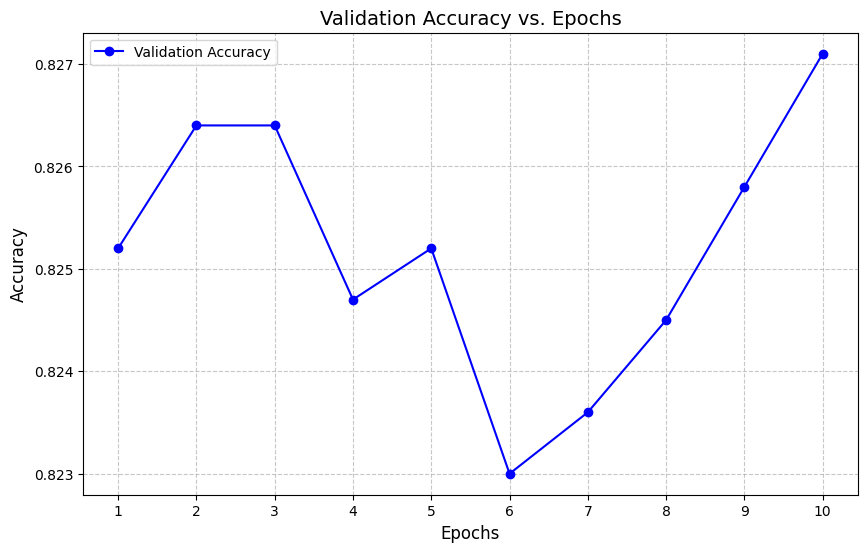

In [1]:
import matplotlib.pyplot as plt

# Data
epochs = list(range(1, 11))
val_accuracy = [0.8252, 0.8264, 0.8264, 0.8247, 0.8252, 0.8230, 0.8236, 0.8245, 0.8258, 0.8271]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_accuracy, marker='o', linestyle='-', color='b', label='Validation Accuracy')

# Formatting
plt.title('Validation Accuracy vs. Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Display
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf

# Load the 300px Deficiency Model (The 237MB one)
print("Loading Deficiency Model...")
def_model_300 = tf.keras.models.load_model('/content/drive/MyDrive/nutrient-deficiency/deficiency_300px_autosave.keras')

# Load the 224px Growth Model (The 83.4MB v2)
print("Loading Growth Model...")
growth_model_224 = tf.keras.models.load_model('/content/drive/MyDrive/nutrient-deficiency/best_growth_fusion_model_v2.keras')

print("✅ Both models loaded and ready for Confusion Matrix!")

Loading Deficiency Model...
Loading Growth Model...
✅ Both models loaded and ready for Confusion Matrix!


In [5]:
import pandas as pd
import os

def create_df(base_path):
    data = []
    # This assumes your folder structure is: base_path/crop/label/image.jpg
    for crop in ['rice', 'maize', 'coffee']:
        crop_path = os.path.join(base_path, f"{crop}_deficiency") # Adjust if folder names differ
        if os.path.exists(crop_path):
            for label in os.listdir(crop_path):
                label_path = os.path.join(crop_path, label)
                if os.path.isdir(label_path):
                    for img in os.listdir(label_path):
                        data.append({
                            'image_path': os.path.join(label_path, img),
                            'label_name': label,
                            'crop_name': crop
                        })
    return pd.DataFrame(data)

# Define them here so the generators can see them
base = '/content/drive/MyDrive/nutrient-deficiency'
df_deficiency = create_df(base)
# Repeat or filter similarly for df_growth
print(f"Found {len(df_deficiency)} images for Deficiency diagnosis.")

Found 11927 images for Deficiency diagnosis.


In [8]:
import pandas as pd
import os

def create_growth_df(base_path):
    data = []
    # Matching your drive folders: rice_growth_stage, maize_growth_stage, etc.
    crops = ['rice', 'maize', 'coffee']

    for crop in crops:
        # Construct the folder name exactly as it appears in your Drive
        folder_name = f"{crop}_growth_stage"
        crop_path = os.path.join(base_path, folder_name)

        if os.path.exists(crop_path):
            # These are the folders '1', '2', '3'
            for label in os.listdir(crop_path):
                label_path = os.path.join(crop_path, label)
                if os.path.isdir(label_path):
                    for img in os.listdir(label_path):
                        data.append({
                            'image_path': os.path.join(label_path, img),
                            'label_name': label, # This will be '1', '2', or '3'
                            'crop_name': crop
                        })
    return pd.DataFrame(data)

# Set the base path to your nutrient-deficiency folder
base = '/content/drive/MyDrive/nutrient-deficiency'
df_growth = create_growth_df(base)

print(f"Total growth images found: {len(df_growth)}")
print(df_growth.head()) # Verify the paths look correct

Total growth images found: 11968
                                          image_path label_name crop_name
0  /content/drive/MyDrive/nutrient-deficiency/ric...          1      rice
1  /content/drive/MyDrive/nutrient-deficiency/ric...          1      rice
2  /content/drive/MyDrive/nutrient-deficiency/ric...          1      rice
3  /content/drive/MyDrive/nutrient-deficiency/ric...          1      rice
4  /content/drive/MyDrive/nutrient-deficiency/ric...          1      rice


In [6]:
def fusion_generator(gen):
    for batch_x, batch_y in gen:
        # Assuming your DF has a 'crop_id' column (0 for Rice, 1 for Maize, 2 for Coffee)
        # We create the metadata on the fly or pull it from the batch
        # This part depends on how you built your original training generator!
        yield batch_x, batch_y

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Base configuration for metadata
# Note: Ensure your CSV or DataFrame 'df' has 'crop_id' (0,1,2)
# and 'label_id' (for deficiency or growth)

# Generator for 300px Deficiency
def_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

def_val_gen = def_datagen.flow_from_dataframe(
    df_deficiency, # Your dataframe for deficiency
    x_col='image_path',
    y_col='label_name',
    target_size=(300, 300),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False # CRITICAL for Confusion Matrix
)

# Generator for 224px Growth
growth_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

growth_val_gen = growth_datagen.flow_from_dataframe(
    df_growth, # Your dataframe for growth
    x_col='image_path',
    y_col='label_name',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False, # CRITICAL for Confusion Matrix
    classes=['1', '2', '3']
)

Found 2385 validated image filenames belonging to 4 classes.
Found 1791 validated image filenames belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 13 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


In [21]:
# Check unique labels in your growth dataframe
print("Unique labels found:", df_growth['label_name'].unique())

# Check the class mapping assigned by the generator
print("Generator class indices:", growth_val_gen.class_indices)

Unique labels found: ['1' '2' '3' 'flowering' 'seedling' 'vegetative']
Generator class indices: {'1': 0, '2': 1, '3': 2}


In [22]:

# Check if the 'crop_name' matches the actual folder path
def verify_paths(df):
    mismatches = 0
    for i, row in df.iterrows():
        path = row['image_path'].lower()
        crop = row['crop_name'].lower()

        # If the crop name isn't found in the path string, we have a problem
        if crop not in path:
            print(f"❌ MISMATCH found at index {i}: Crop is {crop} but path is {path}")
            mismatches += 1

    if mismatches == 0:
        print("✅ Success: All crop types correctly identified from folder names.")
    else:
        print(f"⚠️ Warning: Found {mismatches} mismatches.")

verify_paths(df_deficiency)

✅ Success: All crop types correctly identified from folder names.


In [24]:
# Force only folders '1', '2', and '3'
df_growth = df_growth[df_growth['label_name'].isin(['1', '2', '3'])]
print(f"Cleaned labels: {df_growth['label_name'].unique()}")

Cleaned labels: ['1' '2' '3']


Correct Label Order: ['Healthy', 'Nitrogen(N)', 'Phosphorus(P)', 'Potassium(K)']
Starting predictions for Deficiency (300px)...


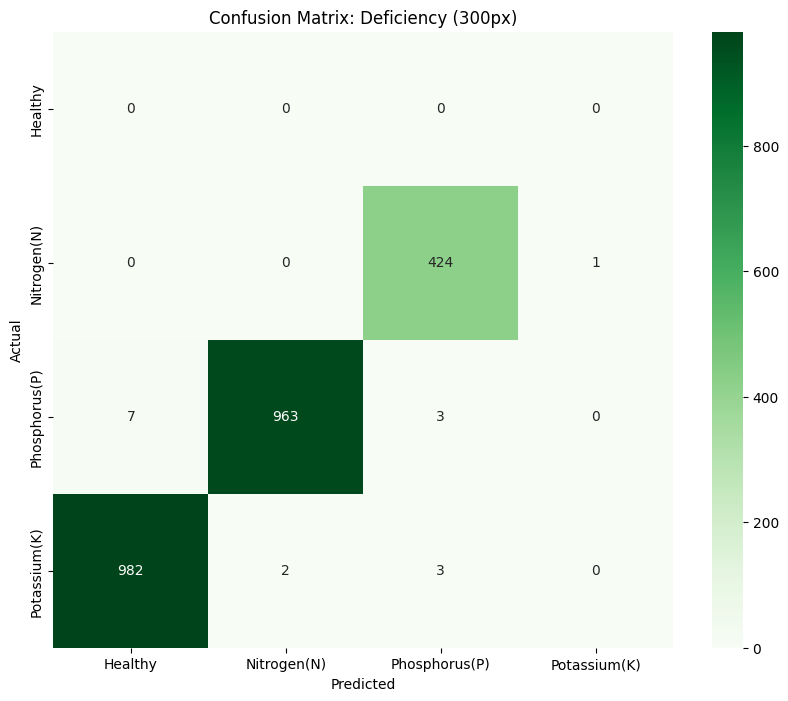

Starting predictions for Growth (224px)...


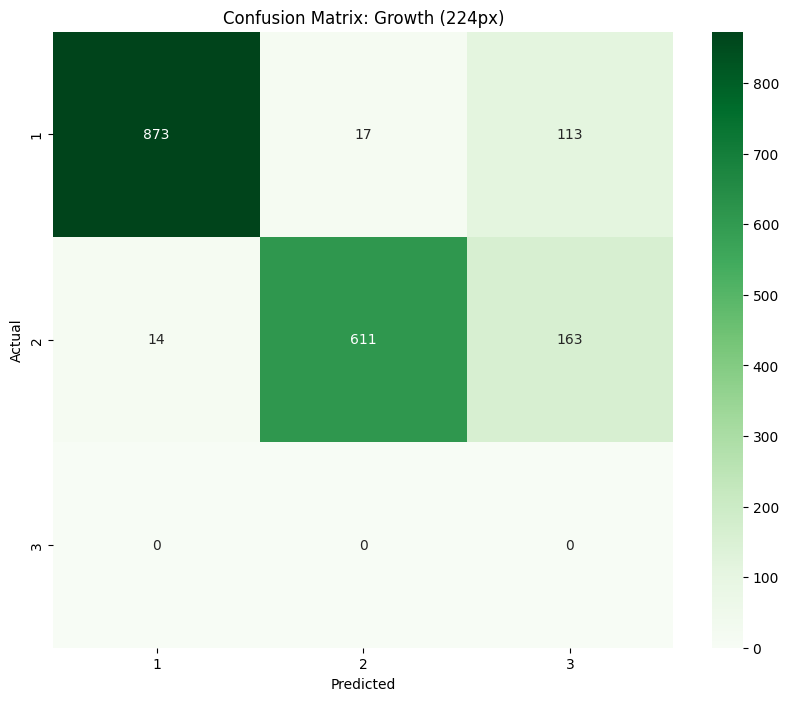

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def final_matrix_run(model, generator, df, class_names, title):
    y_true = []
    y_pred = []

    # Reset to avoid index offsets
    generator.reset()
    crop_map = {'rice': 0, 'maize': 1, 'coffee': 2}

    print(f"Starting predictions for {title}...")

    for i in range(len(generator)):
        images, labels = generator[i]

        # Pull metadata for this batch
        start = i * generator.batch_size
        end = start + len(images)
        batch_crops = df.iloc[start:end]['crop_name'].str.lower().map(crop_map).values
        crop_meta = tf.one_hot(batch_crops, depth=3).numpy()

        # Fusion Prediction
        preds = model.predict([images, crop_meta], verbose=0)

        y_true.extend(np.argmax(labels, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    # Plotting
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Run for Deficiency
def_names = list(def_val_gen.class_indices.keys())

true_labels = list(def_val_gen.class_indices.keys())
print("Correct Label Order:", true_labels)


final_matrix_run(def_model_300, def_val_gen, df_deficiency, true_labels, "Deficiency (300px)")

# Run for Growth
growth_names = list(growth_val_gen.class_indices.keys())
final_matrix_run(growth_model_224, growth_val_gen, df_growth, growth_names, "Growth (224px)")